In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from itertools import product
from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score,mean_absolute_error, median_absolute_error,roc_auc_score
from sklearn.svm import OneClassSVM
from sklearn.model_selection import train_test_split
pd.set_option('display.max_columns', None)

## DATA PREP

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/sebastiansossah/TFM/main/data/df.zip', index_col=0)
df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')
df = df.set_index('Timestamp')
df = df.sort_index()

/tmp/ipython-input-1729006368.py:1: DtypeWarning: Columns (3,4,5,7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('https://raw.githubusercontent.com/sebastiansossah/TFM/main/data/df.zip', index_col=0)


In [3]:
df.shape

(116166, 99)

In [4]:
def create_sliding_windows(df, window_size, stride):
    """
    Crea ventanas deslizantes separando normal vs anomalía
    + metadata para mapeo ventana → evento
    
    Returns:
        windows_train: lista de ventanas normales
        windows_test: lista de ventanas con anomalías
        metadata_train: dict con info de cada ventana train
        metadata_test: dict con info de cada ventana test
    """
    if 'Block_ID' not in df.columns or 'Anomaly_Event' not in df.columns:
        print("Necesitas Block_ID y Anomaly_Event")
        return None, None, None, None
    
    windows_train = []
    windows_test = []
    metadata_train = []
    metadata_test = []
    
    train_idx = 0
    test_idx = 0
    
    for block_id in sorted(df['Block_ID'].unique()):
        block_data = df[df['Block_ID'] == block_id].copy()
        
        for i in range(0, len(block_data) - window_size + 1, stride):
            window = block_data.iloc[i:i+window_size]
            
            meta = {
                'block_id': block_id,
                'start_time': window.index[0],
                'end_time': window.index[-1],
                'start_idx_in_block': i,
                'anomaly_event': int(window['Anomaly_Event'].max()),
                'has_anomaly': bool(window['Anomaly'].any()),
                'n_anomaly_records': int(window['Anomaly'].sum())
            }
            
            if window['Anomaly_Event'].max() > 0:
                meta['window_idx'] = test_idx
                meta['split'] = 'test'
                windows_test.append(window)
                metadata_test.append(meta)
                test_idx += 1
            else:
                meta['window_idx'] = train_idx
                meta['split'] = 'train'
                windows_train.append(window)
                metadata_train.append(meta)
                train_idx += 1
    

    return windows_train, windows_test, metadata_train, metadata_test

In [5]:
def prepare_data_model_with_pca(
        windows_train, 
        windows_test, 
        pca_components=None
    ):
    """
    Prepara datos con normalización diferenciada para sensores/actuadores
    y añade PCA opcional sobre las ventanas flatten.
    """
    continuous_features = [
        'FIT101', 'LIT101',
        'AIT201', 'AIT202', 'AIT203', 'FIT201',
        'AIT301', 'AIT302', 'AIT303', 'DPIT301', 'FIT301', 'LIT301',
        'AIT401', 'AIT402', 'FIT401', 'LIT401',
        'AIT501', 'AIT502', 'AIT503', 'AIT504',
        'FIT501', 'FIT502', 'FIT503', 'FIT504',
        'PIT501', 'PIT502', 'PIT503',
        'FIT601', 'FIT602', 'LIT601', 'LIT602'
    ]
    
    binary_features = [
        'MV101', 'P101', 'P102',
        'MV201', 'P201', 'P202', 'P203', 'P204', 'P205', 'P206',
        'MV301', 'MV302', 'MV303', 'MV304', 'P301', 'P302',
        'P401', 'P402', 'P403', 'P404', 'UV401',
        'MV501', 'MV502', 'MV503', 'MV504', 'P501', 'P502',
        'P601', 'P602', 'P603'
    ]
    
    all_features = continuous_features + binary_features

    X_train = np.array([w[all_features].values for w in windows_train])
    X_test = np.array([w[all_features].values for w in windows_test])
    
    n_cont = len(continuous_features)

    X_train_cont = X_train[:, :, :n_cont]
    X_train_bin  = X_train[:, :, n_cont:]
    X_test_cont  = X_test[:, :, :n_cont]
    X_test_bin   = X_test[:, :, n_cont:]
    
    scaler = StandardScaler()
    
    n_train, window_size, _ = X_train_cont.shape
    
    X_train_cont_rs = X_train_cont.reshape(-1, n_cont)
    X_test_cont_rs  = X_test_cont.reshape(-1, n_cont)
    
    X_train_cont_scaled = scaler.fit_transform(X_train_cont_rs)
    X_test_cont_scaled  = scaler.transform(X_test_cont_rs)
    
    X_train_cont = X_train_cont_scaled.reshape(n_train, window_size, n_cont)
    X_test_cont  = X_test_cont_scaled.reshape(X_test_cont.shape[0], window_size, n_cont)
    
    X_train_final = np.concatenate([X_train_cont, X_train_bin], axis=2)
    X_test_final  = np.concatenate([X_test_cont, X_test_bin], axis=2)

    if pca_components is not None:
        print("\nAplicando PCA...")

        n_features_total = X_train_final.shape[2]
        
        X_train_flat = X_train_final.reshape(X_train_final.shape[0], window_size * n_features_total)
        X_test_flat  = X_test_final.reshape(X_test_final.shape[0], window_size * n_features_total)

        # PCA
        pca = PCA(n_components=pca_components)
        X_train_pca = pca.fit_transform(X_train_flat)
        X_test_pca  = pca.transform(X_test_flat)

        print("Dimensión original:", window_size * n_features_total)
        print("Dimensión PCA:", X_train_pca.shape[1])
        print("Varianza explicada acumulada:", pca.explained_variance_ratio_.sum())

        return X_train_pca, X_test_pca, scaler, pca, all_features
    
    X_train_flat = X_train_final.reshape(X_train_final.shape[0], -1)
    X_test_flat  = X_test_final.reshape(X_test_final.shape[0],  -1)

    return X_train_flat, X_test_flat, scaler, all_features


In [ ]:
def get_scores(model, X_train, X_test, score=0):

    model.fit(X_train)
    if hasattr(model, "decision_scores_"):
        train_scores = model.decision_scores_
        test_scores = model.decision_function(X_test)
        score_direction = "high_is_anomaly"   # PyOD default

    else:
        train_scores = model.decision_function(X_train)
        test_scores = model.decision_function(X_test)
        score_direction = "low_is_anomaly"    # OCSVM default

    y_true = np.concatenate([
        np.zeros(len(train_scores)),
        np.ones(len(test_scores))
    ])

    if score_direction == "high_is_anomaly":
        y_pred = np.concatenate([
            (train_scores > score).astype(int),
            (test_scores > score).astype(int)
        ])
    else:
        y_pred = np.concatenate([
            (train_scores < score).astype(int),
            (test_scores < score).astype(int)
        ])

    f1 = f1_score(y_true, y_pred, zero_division=0)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    mae = mean_absolute_error(y_true, y_pred)
    medae = median_absolute_error(y_true, y_pred)

    pru = np.mean(y_pred[len(train_scores):] == 0)

    return f1, precision, recall, mae, medae, pru


In [ ]:
EXPERIMENT_CONFIG = {
    'strides': [5,15,30],
    'window_size': 60,
    "kernel": ["rbf", "sigmoid"],
    "nu": [0.001, 0.005, 0.01, 0.05],
    "gamma": ["scale", "auto", 0.001, 0.01, 0.1]}

In [9]:

results_svm = []
for stride in EXPERIMENT_CONFIG['strides']:
    windows_train, windows_test, metadata_train, metadata_test = create_sliding_windows(
                    df, 
                    window_size=60, 
                    stride=stride)

    X_train, X_test, scaler, pca, all_features = prepare_data_model_with_pca(
        windows_train, 
        windows_test, 
        pca_components=10)

    for kernel, nu, gamma in product(
            EXPERIMENT_CONFIG["kernel"],
            EXPERIMENT_CONFIG["nu"],
            EXPERIMENT_CONFIG["gamma"]):
        
        ocsvm = OneClassSVM(kernel=kernel, nu=nu, gamma=gamma)
        f1, precision, recall, mae, medae, pru = get_scores(ocsvm, X_train, X_test) 
        results_svm.append({'kernel': kernel, 'nu': nu, 'gamma': gamma,'stride':stride, 
                            'pca':10,'f1': f1, 'precision':precision, 'recall':recall, 'mae':mae, 'medae':medae, 'pru':pru})




Aplicando PCA...
Dimensión original: 3660
Dimensión PCA: 10
Varianza explicada acumulada: 0.8618053986044782

Aplicando PCA...
Dimensión original: 3660
Dimensión PCA: 10
Varianza explicada acumulada: 0.8618467258207725

Aplicando PCA...
Dimensión original: 3660
Dimensión PCA: 10
Varianza explicada acumulada: 0.8617056051807462


In [18]:
df_resultados = pd.DataFrame(results_svm)

In [19]:
len(df_resultados)

120

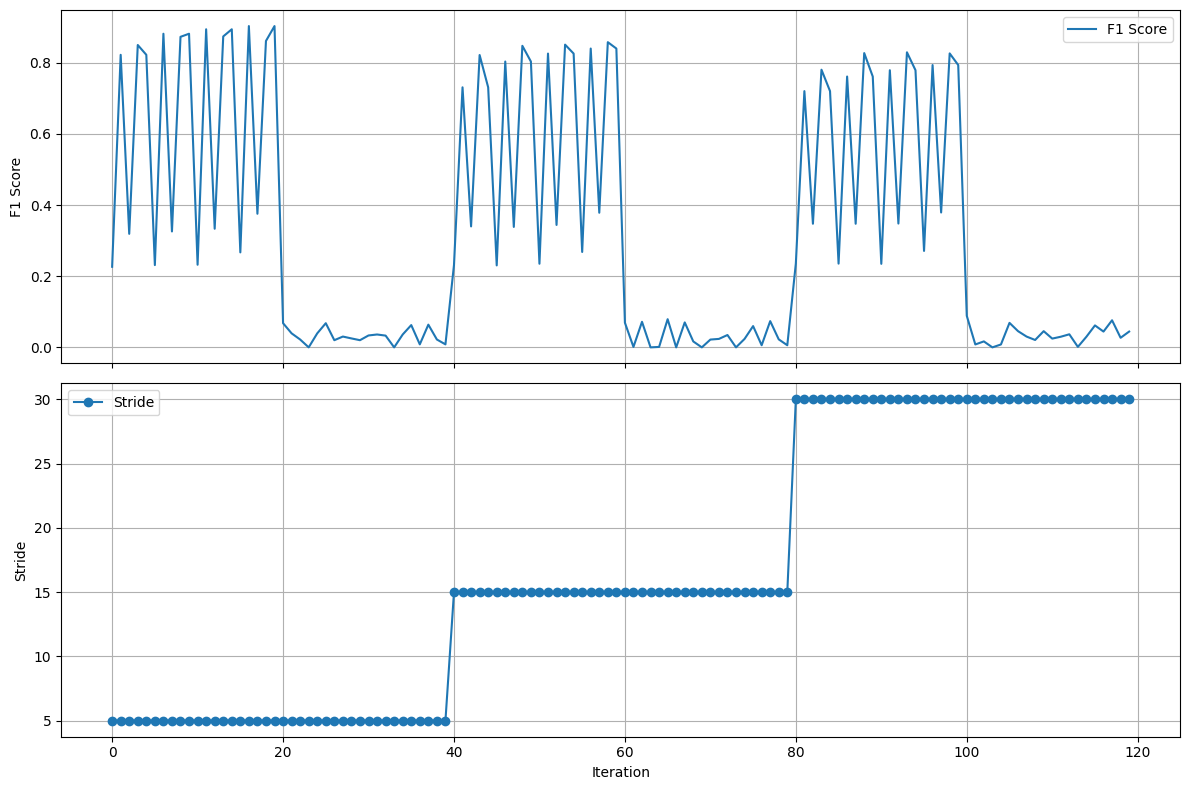

In [23]:
fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# --- F1 plot ---
ax[0].plot(results_df['iteration'], results_df['f1'], label='F1 Score')
ax[0].set_ylabel("F1 Score")
ax[0].grid(True)
ax[0].legend()

# --- Stride plot ---
ax[1].plot(results_df['iteration'], results_df['stride'], label='Stride', linestyle='-', marker='o')
ax[1].set_xlabel("Iteration")
ax[1].set_ylabel("Stride")
ax[1].grid(True)
ax[1].legend()

plt.tight_layout()
plt.show()


In [ ]:
best_by_stride = df_resultados.loc[df_resultados.groupby(["stride"])["f1"].idxmax()]

In [ ]:
best_by_stride

,kernel,nu,gamma,stride,pca,f1,precision,recall,mae,medae,pru
16,rbf,0.05,auto,5,10,0.903394,0.836546,0.981852,0.077079,0.0,0.018148
58,rbf,0.05,0.01,15,10,0.858072,0.880000,0.837209,0.101946,0.0,0.162791
93,rbf,0.01,0.01,30,10,0.829655,0.811741,0.848378,0.128046,0.0,0.151622
